In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mno


In [2]:
# data = pd.read_csv("../Dataset/HAM10000_images_part_1/")
# data = pd.read_csv("../Dataset/HAM10000_images_part_2/")
data_1 = pd.read_csv("../Dataset/hmnist_8_8_L.csv/hmnist_8_8_L.csv")
data_2 = pd.read_csv("../Dataset/hmnist_8_8_RGB.csv/hmnist_8_8_RGB.csv")
data_3 = pd.read_csv("../Dataset/hmnist_28_28_L.csv/hmnist_28_28_L.csv")
data_4 = pd.read_csv("../Dataset/hmnist_28_28_RGB.csv/hmnist_28_28_RGB.csv")
data_5 = pd.read_csv("../Dataset/HAM10000_metadata.csv")


In [3]:
data_1.shape

(10015, 65)

In [4]:
data_1.head()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel0055,pixel0056,pixel0057,pixel0058,pixel0059,pixel0060,pixel0061,pixel0062,pixel0063,label
0,172,182,191,183,180,181,165,164,173,192,...,159,171,181,201,192,184,183,171,157,2
1,98,149,170,193,183,162,164,100,137,175,...,135,83,159,186,185,192,181,143,58,2
2,165,164,179,172,152,163,169,151,168,174,...,169,152,171,185,189,193,176,168,151,2
3,109,159,167,166,163,159,155,96,141,168,...,101,79,146,170,167,158,154,133,45,2
4,173,202,210,194,208,248,243,205,180,142,...,230,160,199,206,208,209,205,200,186,2


In [5]:
data_1.tail()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel0055,pixel0056,pixel0057,pixel0058,pixel0059,pixel0060,pixel0061,pixel0062,pixel0063,label
10010,193,192,191,198,182,191,213,202,199,204,...,202,206,215,211,207,196,212,205,191,0
10011,93,139,165,183,188,180,150,65,147,164,...,137,145,185,194,186,183,180,161,88,0
10012,165,191,211,227,222,208,210,164,193,203,...,189,184,223,227,218,217,223,207,182,0
10013,138,152,154,161,173,177,179,171,144,157,...,172,143,161,167,166,174,184,175,168,0
10014,152,152,150,148,156,159,158,163,153,155,...,140,143,151,153,156,157,163,117,120,6


In [6]:
data_1["pixel0000"]

0        172
1         98
2        165
3        109
4        173
        ... 
10010    193
10011     93
10012    165
10013    138
10014    152
Name: pixel0000, Length: 10015, dtype: int64

In [7]:
data_1.iloc[0]

pixel0000    172
pixel0001    182
pixel0002    191
pixel0003    183
pixel0004    180
            ... 
pixel0060    184
pixel0061    183
pixel0062    171
pixel0063    157
label          2
Name: 0, Length: 65, dtype: int64

In [8]:
data_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 65 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   pixel0000  10015 non-null  int64
 1   pixel0001  10015 non-null  int64
 2   pixel0002  10015 non-null  int64
 3   pixel0003  10015 non-null  int64
 4   pixel0004  10015 non-null  int64
 5   pixel0005  10015 non-null  int64
 6   pixel0006  10015 non-null  int64
 7   pixel0007  10015 non-null  int64
 8   pixel0008  10015 non-null  int64
 9   pixel0009  10015 non-null  int64
 10  pixel0010  10015 non-null  int64
 11  pixel0011  10015 non-null  int64
 12  pixel0012  10015 non-null  int64
 13  pixel0013  10015 non-null  int64
 14  pixel0014  10015 non-null  int64
 15  pixel0015  10015 non-null  int64
 16  pixel0016  10015 non-null  int64
 17  pixel0017  10015 non-null  int64
 18  pixel0018  10015 non-null  int64
 19  pixel0019  10015 non-null  int64
 20  pixel0020  10015 non-null  int64
 21  pixel0021  10015 non-nu

In [9]:
data_1.describe()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel0055,pixel0056,pixel0057,pixel0058,pixel0059,pixel0060,pixel0061,pixel0062,pixel0063,label
count,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,...,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000
mean,156.511533,167.292461,171.177933,171.134199,171.372641,171.535597,167.875087,156.103045,161.946880,168.198203,...,159.674488,152.949176,164.089965,167.266400,167.077983,167.451423,167.852322,164.511233,152.323615,3.720919
std,37.482126,26.222928,23.467171,23.795547,23.776595,23.354094,25.726513,37.252888,29.992239,24.419041,...,29.590557,35.247465,25.029972,23.892399,24.556616,24.237219,23.627575,25.727107,37.570423,1.347499
min,0.000000,2.000000,12.000000,25.000000,13.000000,1.000000,1.000000,0.000000,0.000000,3.000000,...,2.000000,1.000000,2.000000,4.000000,1.000000,0.000000,0.000000,5.000000,0.000000,0.000000
25%,143.000000,153.000000,157.000000,157.000000,157.000000,157.000000,153.000000,141.000000,148.000000,154.000000,...,145.000000,139.000000,149.000000,153.000000,152.000000,153.000000,153.000000,149.000000,138.000000,4.000000
50%,163.000000,169.000000,172.000000,172.000000,173.000000,173.000000,170.000000,163.000000,165.000000,169.000000,...,163.000000,159.000000,165.000000,168.000000,168.000000,168.000000,169.000000,166.000000,159.000000,4.000000
75%,179.000000,184.000000,186.000000,186.000000,187.000000,187.000000,185.000000,180.000000,180.000000,184.000000,...,178.000000,174.000000,180.000000,182.000000,183.000000,183.000000,183.000000,181.000000,176.000000,4.000000
max,251.000000,255.000000,253.000000,249.000000,249.000000,255.000000,252.000000,242.000000,255.000000,249.000000,...,252.000000,251.000000,255.000000,254.000000,248.000000,248.000000,253.000000,255.000000,252.000000,6.000000


In [10]:
data_1.isnull().sum().sum()

np.int64(0)

In [11]:
data_1.duplicated().sum()

np.int64(2)

# hmnist_8_8_RGB.csv datas

In [12]:
data_2.shape

(10015, 193)

In [13]:
data_2.head()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel0183,pixel0184,pixel0185,pixel0186,pixel0187,pixel0188,pixel0189,pixel0190,pixel0191,label
0,199,156,188,210,165,198,216,176,203,215,...,214,167,191,199,157,175,184,143,167,2
1,115,87,115,180,133,158,200,153,187,215,...,207,167,188,177,128,138,74,51,60,2
2,203,146,164,209,144,153,217,160,181,215,...,211,160,175,199,152,172,177,138,158,2
3,135,96,110,198,141,156,208,148,158,210,...,179,141,157,153,122,138,58,39,46,2
4,204,156,187,232,185,216,236,196,220,217,...,236,189,213,233,182,209,207,175,188,2


In [14]:
data_2.tail()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel0183,pixel0184,pixel0185,pixel0186,pixel0187,pixel0188,pixel0189,pixel0190,pixel0191,label
10010,205,186,202,208,184,194,211,183,188,221,...,229,205,211,218,199,202,207,185,186,0
10011,103,89,88,156,133,134,183,157,159,205,...,199,172,173,179,154,152,99,84,80,0
10012,178,160,165,206,184,190,228,204,210,242,...,241,216,216,224,201,199,197,177,172,0
10013,166,124,142,179,138,156,186,138,156,188,...,195,178,187,191,168,177,186,159,169,0
10014,178,145,124,178,145,123,177,143,118,176,...,185,158,138,163,100,88,163,105,91,6


In [15]:
data_2["pixel0000"]

0        199
1        115
2        203
3        135
4        204
        ... 
10010    205
10011    103
10012    178
10013    166
10014    178
Name: pixel0000, Length: 10015, dtype: int64

In [16]:
data_2.iloc[0]

pixel0000    199
pixel0001    156
pixel0002    188
pixel0003    210
pixel0004    165
            ... 
pixel0188    175
pixel0189    184
pixel0190    143
pixel0191    167
label          2
Name: 0, Length: 193, dtype: int64

In [17]:
data_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Columns: 193 entries, pixel0000 to label
dtypes: int64(193)
memory usage: 14.7 MB


In [18]:
data_2.describe()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel0183,pixel0184,pixel0185,pixel0186,pixel0187,pixel0188,pixel0189,pixel0190,pixel0191,label
count,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,...,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000
mean,191.213979,140.838542,150.552072,202.931902,151.092961,161.620469,207.623864,154.623764,165.228757,208.460909,...,202.643934,152.575237,159.603894,198.157264,149.824463,156.272691,184.489466,138.401697,144.028857,3.720919
std,46.825874,36.116935,39.203640,32.578025,27.896053,30.500041,27.706896,26.914945,29.534754,26.969178,...,26.506185,26.404099,29.828338,30.246807,27.083010,30.470677,44.876041,36.347016,39.255034,1.347499
min,0.000000,0.000000,0.000000,0.000000,3.000000,4.000000,15.000000,12.000000,0.000000,52.000000,...,3.000000,0.000000,0.000000,9.000000,4.000000,6.000000,1.000000,0.000000,0.000000,0.000000
25%,169.000000,126.000000,133.000000,182.000000,135.000000,144.000000,188.000000,138.000000,147.000000,189.000000,...,185.000000,136.000000,141.000000,179.000000,133.000000,137.000000,165.000000,123.000000,125.000000,4.000000
50%,202.000000,145.000000,155.000000,208.000000,151.000000,163.000000,211.000000,155.000000,166.000000,211.000000,...,206.000000,153.000000,160.000000,203.000000,150.000000,156.000000,197.000000,143.000000,148.000000,4.000000
75%,225.000000,162.000000,174.000000,228.000000,168.000000,180.000000,230.000000,171.000000,184.000000,230.000000,...,223.000000,169.000000,178.000000,221.000000,167.000000,175.000000,216.000000,161.000000,168.000000,4.000000
max,255.000000,251.000000,255.000000,255.000000,255.000000,255.000000,255.000000,253.000000,255.000000,255.000000,...,255.000000,254.000000,255.000000,255.000000,255.000000,255.000000,255.000000,252.000000,255.000000,6.000000


In [19]:
data_2.isnull().sum().sum()

np.int64(0)

In [20]:
data_2.duplicated().sum()

np.int64(2)

# hmnist_28_28_L.csv datas

In [21]:
data_3.shape

(10015, 785)

In [22]:
data_3.head()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel0775,pixel0776,pixel0777,pixel0778,pixel0779,pixel0780,pixel0781,pixel0782,pixel0783,label
0,169,171,170,177,181,182,181,185,194,192,...,184,186,185,180,157,140,140,159,165,2
1,19,57,105,140,149,148,144,155,170,170,...,172,175,160,144,114,89,47,18,18,2
2,155,163,161,167,167,172,155,152,165,175,...,163,178,157,166,167,148,141,136,115,2
3,25,71,116,139,136,153,148,161,172,162,...,125,135,138,137,111,71,32,16,16,2
4,129,162,181,196,205,208,205,213,225,224,...,210,197,172,190,195,193,181,147,88,2


In [23]:
data_3.tail()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel0775,pixel0776,pixel0777,pixel0778,pixel0779,pixel0780,pixel0781,pixel0782,pixel0783,label
10010,172,171,173,175,164,187,207,210,208,206,...,210,217,221,209,185,187,192,192,192,0
10011,2,34,108,116,114,119,131,139,139,145,...,173,169,168,168,143,138,83,23,3,0
10012,122,154,162,170,179,197,200,195,202,199,...,221,215,205,187,209,198,187,164,156,0
10013,137,143,141,139,147,152,155,152,155,159,...,172,171,175,183,177,170,169,166,170,0
10014,149,157,157,152,151,152,154,163,149,145,...,159,154,145,106,67,62,103,146,148,6


In [24]:
data_3["pixel0000"]

0        169
1         19
2        155
3         25
4        129
        ... 
10010    172
10011      2
10012    122
10013    137
10014    149
Name: pixel0000, Length: 10015, dtype: int64

In [25]:
data_3.iloc[0]

pixel0000    169
pixel0001    171
pixel0002    170
pixel0003    177
pixel0004    181
            ... 
pixel0780    140
pixel0781    140
pixel0782    159
pixel0783    165
label          2
Name: 0, Length: 785, dtype: int64

In [26]:
data_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Columns: 785 entries, pixel0000 to label
dtypes: int64(785)
memory usage: 60.0 MB


In [27]:
data_3.describe()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel0775,pixel0776,pixel0777,pixel0778,pixel0779,pixel0780,pixel0781,pixel0782,pixel0783,label
count,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,...,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000
mean,147.070894,152.760459,157.600799,161.083974,164.170644,166.832252,168.773839,170.279780,171.318422,172.058213,...,167.020769,166.026460,164.834648,163.231453,160.781128,156.980829,152.397703,146.934398,141.265402,3.720919
std,48.203980,43.474167,38.849857,35.319100,31.777087,28.001220,25.836775,24.820715,24.149374,23.752983,...,24.519133,25.029717,25.826189,27.013780,29.412054,34.210474,39.703941,45.032512,49.148214,1.347499
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5.000000,6.000000,8.000000,...,4.000000,4.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,133.000000,140.000000,144.000000,147.000000,150.000000,152.000000,154.000000,156.000000,157.000000,157.000000,...,152.000000,151.000000,149.000000,148.000000,146.000000,143.000000,139.000000,134.000000,128.000000,4.000000
50%,160.000000,163.000000,165.000000,166.000000,168.000000,169.000000,171.000000,172.000000,173.000000,173.000000,...,168.000000,167.000000,166.000000,165.000000,164.000000,162.000000,160.000000,157.000000,154.000000,4.000000
75%,177.000000,179.000000,181.000000,182.000000,184.000000,184.000000,185.000000,186.000000,187.000000,187.000000,...,183.000000,182.000000,181.000000,180.000000,179.000000,178.000000,176.000000,174.000000,172.000000,4.000000
max,247.000000,248.000000,252.000000,253.000000,255.000000,255.000000,254.000000,255.000000,255.000000,254.000000,...,254.000000,254.000000,252.000000,252.000000,253.000000,252.000000,254.000000,252.000000,251.000000,6.000000


In [28]:
data_3.isnull().sum().sum()

np.int64(0)

In [29]:
data_3.duplicated().sum()

np.int64(2)

# hmnist_28_28_RGB.csv datas

In [30]:
data_4.shape

(10015, 2353)

In [31]:
data_4.head()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2


In [32]:
data_4.tail()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
10010,183,165,181,182,165,180,184,166,182,188,...,208,185,187,208,186,186,206,187,189,0
10011,2,3,1,38,33,32,121,104,103,132,...,96,79,76,24,23,21,3,4,1,0
10012,132,118,118,167,149,149,175,156,160,184,...,204,181,178,181,159,153,172,151,145,0
10013,160,124,146,164,131,152,167,127,146,169,...,185,162,167,184,157,166,185,162,172,0
10014,175,142,121,181,150,134,181,150,133,178,...,159,79,82,174,137,125,175,139,126,6


In [33]:
data_4["pixel0000"]

0        192
1         25
2        192
3         38
4        158
        ... 
10010    183
10011      2
10012    132
10013    160
10014    175
Name: pixel0000, Length: 10015, dtype: int64

In [34]:
data_4.iloc[0]

pixel0000    192
pixel0001    153
pixel0002    193
pixel0003    195
pixel0004    155
            ... 
pixel2348    166
pixel2349    185
pixel2350    154
pixel2351    177
label          2
Name: 0, Length: 2353, dtype: int64

In [35]:
data_4.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Columns: 2353 entries, pixel0000 to label
dtypes: int64(2353)
memory usage: 179.8 MB


In [36]:
data_4.describe()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
count,10015.000000,10015.000000,10015.00000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,...,10015.00000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000
mean,181.056415,131.728407,141.24024,187.274488,137.089466,147.206191,192.358862,141.796405,152.211782,196.177234,...,184.68657,138.416875,144.061508,178.656216,133.217474,138.752172,172.307239,127.871193,133.144483,3.720919
std,59.746698,45.043473,48.67267,54.021274,41.138096,44.661091,48.267713,37.382709,40.725174,43.892249,...,47.02376,38.393007,41.322365,53.534096,42.910723,45.642257,58.533979,46.453818,49.060028,1.347499
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,158.000000,117.000000,123.00000,165.000000,122.000000,130.000000,170.000000,127.000000,135.000000,174.000000,...,166.00000,123.000000,126.000000,160.000000,118.000000,120.000000,153.000000,113.000000,115.000000,4.000000
50%,198.000000,141.000000,151.00000,201.000000,144.000000,155.000000,204.000000,146.000000,157.000000,205.000000,...,197.00000,144.000000,149.000000,195.000000,141.000000,146.000000,191.000000,138.000000,142.000000,4.000000
75%,224.000000,159.000000,172.00000,226.000000,162.000000,174.000000,227.000000,163.000000,177.000000,228.000000,...,216.00000,161.000000,169.000000,214.000000,159.000000,166.000000,212.000000,156.000000,163.000000,4.000000
max,255.000000,246.000000,255.00000,254.000000,246.000000,254.000000,255.000000,251.000000,255.000000,255.000000,...,255.00000,254.000000,254.000000,254.000000,252.000000,255.000000,254.000000,249.000000,254.000000,6.000000


In [37]:
data_4.isnull().sum().sum()

np.int64(0)

In [38]:
data_4.duplicated().sum()

np.int64(2)

# MetaData HAM10000 csv datas

In [39]:
data_5.shape

(10015, 7)

In [40]:
data_5.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [41]:
data_5.tail()

,lesion_id,image_id,dx,dx_type,age,sex,localization
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face
10014,HAM_0003521,ISIC_0032258,mel,histo,70.0,female,back


In [42]:
data_5["lesion_id"]

0        HAM_0000118
1        HAM_0000118
2        HAM_0002730
3        HAM_0002730
4        HAM_0001466
            ...     
10010    HAM_0002867
10011    HAM_0002867
10012    HAM_0002867
10013    HAM_0000239
10014    HAM_0003521
Name: lesion_id, Length: 10015, dtype: str

In [43]:
data_5.iloc[0]

lesion_id        HAM_0000118
image_id        ISIC_0027419
dx                       bkl
dx_type                histo
age                     80.0
sex                     male
localization           scalp
Name: 0, dtype: object

In [44]:
data_5.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


In [45]:
data_5.describe(include="all")

,lesion_id,image_id,dx,dx_type,age,sex,localization
count,10015,10015,10015,10015,9958.000000,10015,10015
unique,7470,10015,7,4,NaN,3,15
top,HAM_0003789,ISIC_0027419,nv,histo,NaN,male,back
freq,6,1,6705,5340,NaN,5406,2192
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN


In [46]:
data_5.isnull().sum().sum()

np.int64(57)

In [47]:
data_5.duplicated().sum()

np.int64(0)

In [48]:
data_5["dx"].unique()

<StringArray>
['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
Length: 7, dtype: str

In [49]:
data_5["dx_type"].unique()

<StringArray>
['histo', 'consensus', 'confocal', 'follow_up']
Length: 4, dtype: str

In [50]:
import cv2
import os

In [51]:
path = os.getcwd()

In [52]:
path = "../Dataset/HAM10000_images_part_1"

In [66]:
img = cv2.imread("../Dataset/HAM10000_images_part_1/ISIC_0024306.jpg")
img.shape

(450, 600, 3)

In [63]:
shape_array = {}

for image in os.listdir(path):
    img_path = path + "/" + image
    img = cv2.imread(img_path)
    shape_array[img_path] = img.shape


In [64]:
shape_array

{'../Dataset/HAM10000_images_part_1/ISIC_0024306.jpg': (450, 600, 3),
 '../Dataset/HAM10000_images_part_1/ISIC_0024307.jpg': (450, 600, 3),
 '../Dataset/HAM10000_images_part_1/ISIC_0024308.jpg': (450, 600, 3),
 '../Dataset/HAM10000_images_part_1/ISIC_0024309.jpg': (450, 600, 3),
 '../Dataset/HAM10000_images_part_1/ISIC_0024310.jpg': (450, 600, 3),
 '../Dataset/HAM10000_images_part_1/ISIC_0024311.jpg': (450, 600, 3),
 '../Dataset/HAM10000_images_part_1/ISIC_0024312.jpg': (450, 600, 3),
 '../Dataset/HAM10000_images_part_1/ISIC_0024313.jpg': (450, 600, 3),
 '../Dataset/HAM10000_images_part_1/ISIC_0024314.jpg': (450, 600, 3),
 '../Dataset/HAM10000_images_part_1/ISIC_0024315.jpg': (450, 600, 3),
 '../Dataset/HAM10000_images_part_1/ISIC_0024316.jpg': (450, 600, 3),
 '../Dataset/HAM10000_images_part_1/ISIC_0024317.jpg': (450, 600, 3),
 '../Dataset/HAM10000_images_part_1/ISIC_0024318.jpg': (450, 600, 3),
 '../Dataset/HAM10000_images_part_1/ISIC_0024319.jpg': (450, 600, 3),
 '../Dataset/HAM1000

# Class Distribution

C:\Users\Dell\AppData\Local\Temp\ipykernel_22284\401755928.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data_5["dx"],palette="viridis")


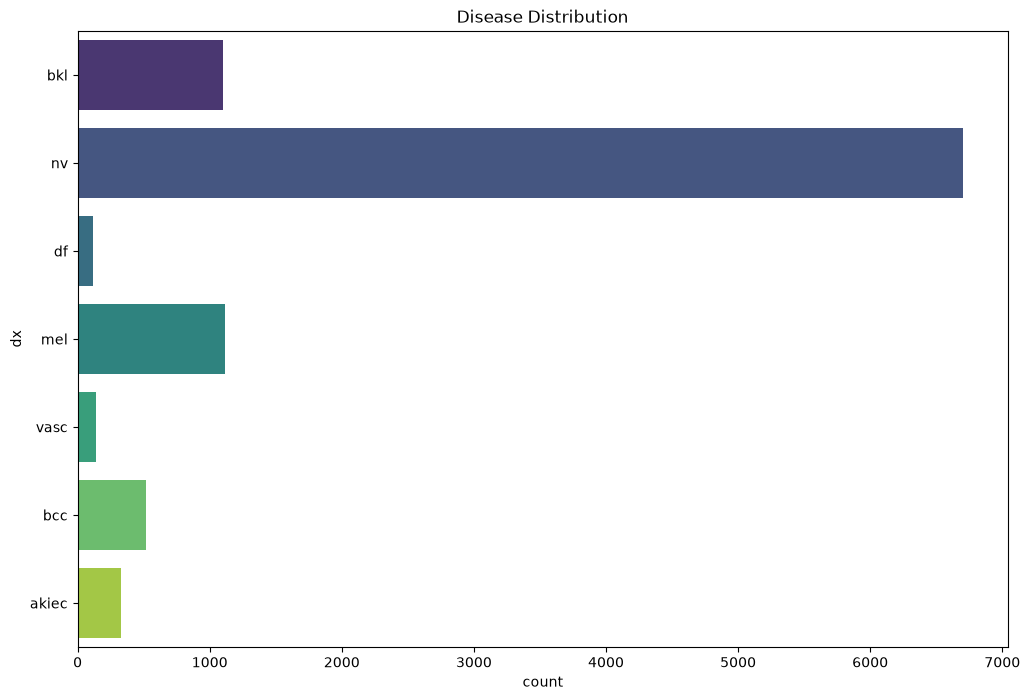

In [ ]:
plt.figure(figsize=(12,8))

sns.countplot(data_5["dx"],palette="viridis")

plt.title("Disease Distribution")

plt.show()

In [68]:
data_5["dx"].value_counts(normalize=True)*100

dx
nv       66.949576
mel      11.113330
bkl      10.973540
bcc       5.132302
akiec     3.265102
vasc      1.417873
df        1.148278
Name: proportion, dtype: float64

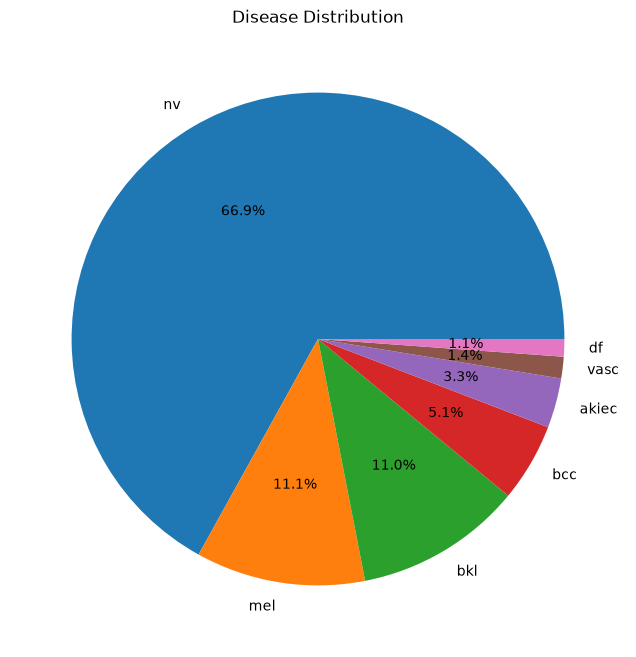

In [69]:
plt.figure(figsize=(8,8))

data_5["dx"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Disease Distribution")
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_22284\1105282548.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


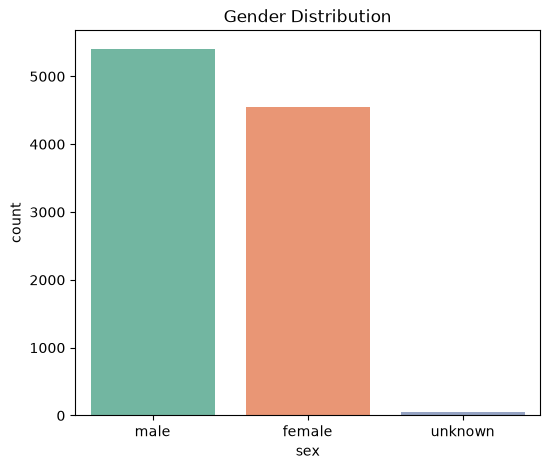

In [70]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=data_5,
    x="sex",
    palette="Set2"
)

plt.title("Gender Distribution")
plt.show()

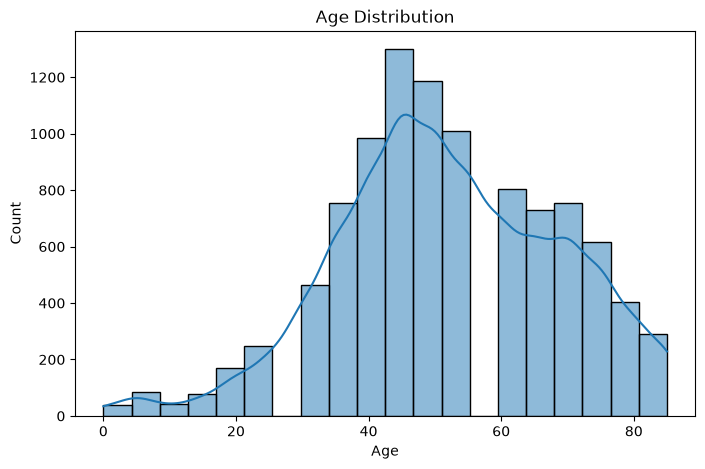

In [71]:
plt.figure(figsize=(8,5))

sns.histplot(
    data_5["age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

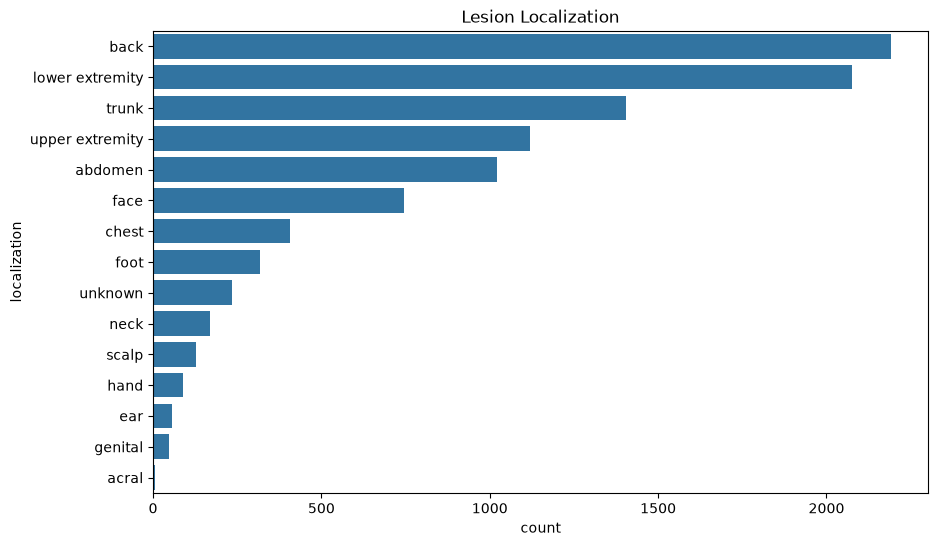

In [72]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=data_5,
    y="localization",
    order=data_5["localization"].value_counts().index
)

plt.title("Lesion Localization")
plt.show()

In [74]:
image_dir1 = "../Dataset/HAM10000_images_part_1"
image_dir2 = "../Dataset/HAM10000_images_part_2"

image_paths = {}

for folder in [image_dir1, image_dir2]:

    for img in os.listdir(folder):

        image_id = img.split(".")[0]

        image_paths[image_id] = os.path.join(folder,img)

data_5["path"] = data_5["image_id"].map(image_paths)

data_5.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../Dataset/HAM10000_images_part_1\ISIC_0027419...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../Dataset/HAM10000_images_part_1\ISIC_0025030...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../Dataset/HAM10000_images_part_1\ISIC_0026769...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../Dataset/HAM10000_images_part_1\ISIC_0025661...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../Dataset/HAM10000_images_part_2\ISIC_0031633...


In [75]:
sample = cv2.imread(data_5.iloc[0]["path"])

print(sample.shape)

(450, 600, 3)


In [77]:
heights = []
widths = []

for path in data_5["path"]:

    img = cv2.imread(path)

    h,w,_ = img.shape

    heights.append(h)
    widths.append(w)

data_5["Height"] = heights
data_5["Width"] = widths

In [78]:
data_5.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,Height,Width
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../Dataset/HAM10000_images_part_1\ISIC_0027419...,450,600
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../Dataset/HAM10000_images_part_1\ISIC_0025030...,450,600
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../Dataset/HAM10000_images_part_1\ISIC_0026769...,450,600
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../Dataset/HAM10000_images_part_1\ISIC_0025661...,450,600
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../Dataset/HAM10000_images_part_2\ISIC_0031633...,450,600


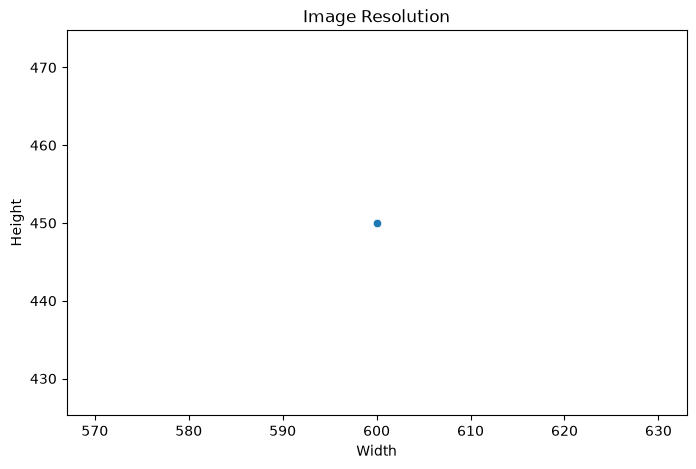

In [79]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=data_5["Width"],
    y=data_5["Height"]
)

plt.title("Image Resolution")
plt.show()

In [80]:
from sklearn.model_selection import train_test_split

In [88]:
train_df, temp_df = train_test_split( data_5, test_size=0.2, random_state=42, stratify=data_5["dx"] )

In [89]:
train_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,Height,Width
8050,HAM_0005972,ISIC_0033319,nv,histo,35.0,female,lower extremity,../Dataset/HAM10000_images_part_2\ISIC_0033319...,450,600
4898,HAM_0004902,ISIC_0030823,nv,follow_up,40.0,male,trunk,../Dataset/HAM10000_images_part_2\ISIC_0030823...,450,600
9695,HAM_0005282,ISIC_0028730,akiec,histo,65.0,male,lower extremity,../Dataset/HAM10000_images_part_1\ISIC_0028730...,450,600
4090,HAM_0000475,ISIC_0027299,nv,follow_up,40.0,male,lower extremity,../Dataset/HAM10000_images_part_1\ISIC_0027299...,450,600
8625,HAM_0000949,ISIC_0032444,nv,histo,65.0,male,back,../Dataset/HAM10000_images_part_2\ISIC_0032444...,450,600
...,...,...,...,...,...,...,...,...,...,...
2360,HAM_0000940,ISIC_0032692,vasc,histo,35.0,female,lower extremity,../Dataset/HAM10000_images_part_2\ISIC_0032692...,450,600
3409,HAM_0005629,ISIC_0029317,nv,follow_up,45.0,female,upper extremity,../Dataset/HAM10000_images_part_2\ISIC_0029317...,450,600
8736,HAM_0004025,ISIC_0025983,nv,histo,20.0,female,abdomen,../Dataset/HAM10000_images_part_1\ISIC_0025983...,450,600
2399,HAM_0004542,ISIC_0027256,vasc,consensus,0.0,female,back,../Dataset/HAM10000_images_part_1\ISIC_0027256...,450,600


In [91]:
temp_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,Height,Width
9658,HAM_0001956,ISIC_0030038,nv,consensus,30.0,female,back,../Dataset/HAM10000_images_part_2\ISIC_0030038...,450,600
6784,HAM_0002652,ISIC_0025442,nv,histo,25.0,male,lower extremity,../Dataset/HAM10000_images_part_1\ISIC_0025442...,450,600
1918,HAM_0001532,ISIC_0027204,mel,histo,70.0,male,neck,../Dataset/HAM10000_images_part_1\ISIC_0027204...,450,600
8322,HAM_0003345,ISIC_0032165,nv,histo,70.0,male,chest,../Dataset/HAM10000_images_part_2\ISIC_0032165...,450,600
932,HAM_0004113,ISIC_0033185,bkl,consensus,55.0,female,lower extremity,../Dataset/HAM10000_images_part_2\ISIC_0033185...,450,600
...,...,...,...,...,...,...,...,...,...,...
7597,HAM_0001889,ISIC_0034116,nv,histo,35.0,female,trunk,../Dataset/HAM10000_images_part_2\ISIC_0034116...,450,600
2586,HAM_0003328,ISIC_0026453,bcc,histo,55.0,female,back,../Dataset/HAM10000_images_part_1\ISIC_0026453...,450,600
2169,HAM_0000856,ISIC_0029885,mel,histo,35.0,male,back,../Dataset/HAM10000_images_part_2\ISIC_0029885...,450,600
1815,HAM_0000799,ISIC_0033226,mel,histo,65.0,male,upper extremity,../Dataset/HAM10000_images_part_2\ISIC_0033226...,450,600


In [92]:
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["dx"]
)

In [93]:
valid_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,Height,Width
3962,HAM_0005031,ISIC_0025109,nv,follow_up,65.0,male,abdomen,../Dataset/HAM10000_images_part_1\ISIC_0025109...,450,600
1161,HAM_0006188,ISIC_0024330,df,consensus,40.0,male,lower extremity,../Dataset/HAM10000_images_part_1\ISIC_0024330...,450,600
6361,HAM_0007094,ISIC_0026785,nv,follow_up,30.0,female,lower extremity,../Dataset/HAM10000_images_part_1\ISIC_0026785...,450,600
9191,HAM_0006129,ISIC_0029560,nv,histo,45.0,male,lower extremity,../Dataset/HAM10000_images_part_2\ISIC_0029560...,450,600
7190,HAM_0005351,ISIC_0032590,nv,histo,20.0,female,lower extremity,../Dataset/HAM10000_images_part_2\ISIC_0032590...,450,600
...,...,...,...,...,...,...,...,...,...,...
5846,HAM_0001187,ISIC_0027914,nv,follow_up,45.0,male,trunk,../Dataset/HAM10000_images_part_1\ISIC_0027914...,450,600
4356,HAM_0006973,ISIC_0029377,nv,follow_up,60.0,male,trunk,../Dataset/HAM10000_images_part_2\ISIC_0029377...,450,600
623,HAM_0006723,ISIC_0026365,bkl,histo,45.0,male,lower extremity,../Dataset/HAM10000_images_part_1\ISIC_0026365...,450,600
4406,HAM_0000434,ISIC_0031635,nv,follow_up,45.0,female,trunk,../Dataset/HAM10000_images_part_2\ISIC_0031635...,450,600


In [94]:
test_df


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,Height,Width
6981,HAM_0006303,ISIC_0026911,nv,histo,55.0,male,abdomen,../Dataset/HAM10000_images_part_1\ISIC_0026911...,450,600
4116,HAM_0002614,ISIC_0027637,nv,follow_up,75.0,male,trunk,../Dataset/HAM10000_images_part_1\ISIC_0027637...,450,600
5391,HAM_0004362,ISIC_0031873,nv,follow_up,45.0,female,lower extremity,../Dataset/HAM10000_images_part_2\ISIC_0031873...,450,600
1997,HAM_0006207,ISIC_0030034,mel,histo,50.0,female,back,../Dataset/HAM10000_images_part_2\ISIC_0030034...,450,600
7154,HAM_0000801,ISIC_0025619,nv,histo,20.0,female,back,../Dataset/HAM10000_images_part_1\ISIC_0025619...,450,600
...,...,...,...,...,...,...,...,...,...,...
6797,HAM_0006197,ISIC_0028332,nv,histo,40.0,male,back,../Dataset/HAM10000_images_part_1\ISIC_0028332...,450,600
4047,HAM_0006935,ISIC_0026628,nv,follow_up,50.0,male,back,../Dataset/HAM10000_images_part_1\ISIC_0026628...,450,600
1261,HAM_0004607,ISIC_0031642,mel,histo,50.0,female,back,../Dataset/HAM10000_images_part_2\ISIC_0031642...,450,600
8801,HAM_0004399,ISIC_0028905,nv,histo,20.0,female,face,../Dataset/HAM10000_images_part_1\ISIC_0028905...,450,600


In [95]:
print("Training :", train_df.shape)
print("Validation :", valid_df.shape)
print("Testing :", test_df.shape)

Training : (8012, 10)
Validation : (1001, 10)
Testing : (1002, 10)


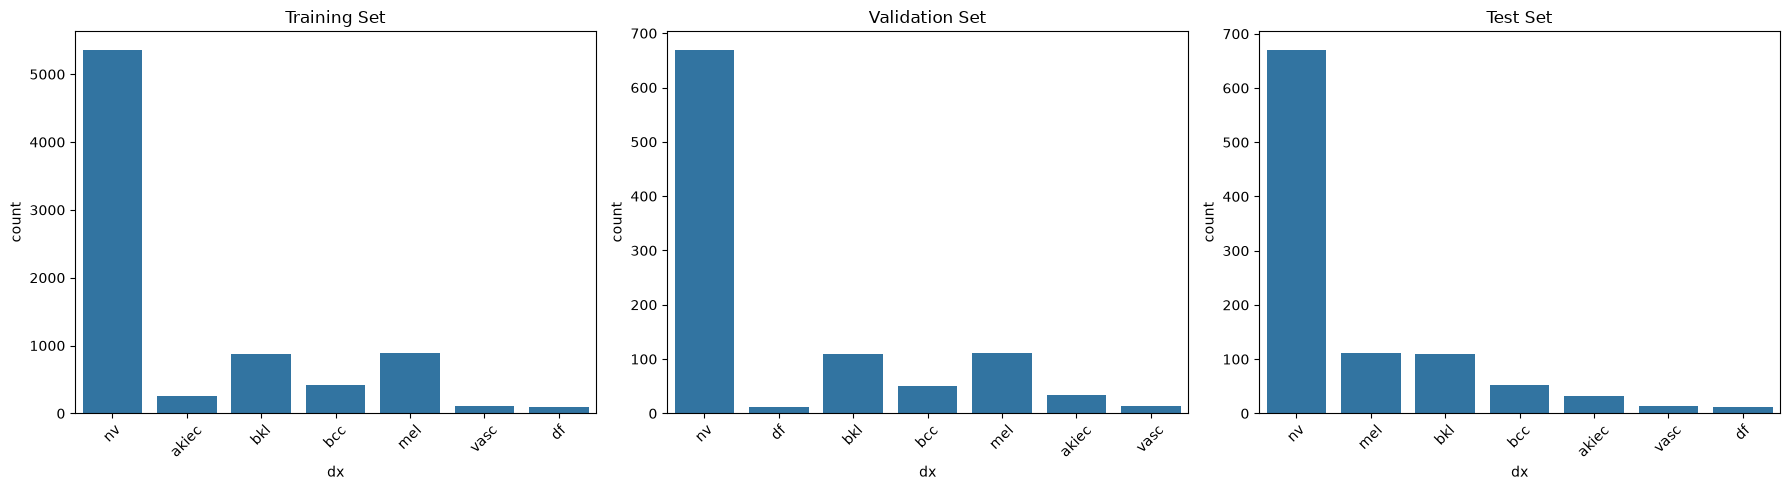

In [96]:
fig, axes = plt.subplots(1,3,figsize=(18,5))

sns.countplot(data=train_df, x="dx", ax=axes[0])
axes[0].set_title("Training Set")

sns.countplot(data=valid_df, x="dx", ax=axes[1])
axes[1].set_title("Validation Set")

sns.countplot(data=test_df, x="dx", ax=axes[2])
axes[2].set_title("Test Set")

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [99]:
train_df.to_csv("../Dataset/train_metadata.csv", index=False)
valid_df.to_csv("../Dataset/valid_metadata.csv", index=False)
test_df.to_csv("../Dataset/test_metadata.csv", index=False)